In [1]:
from operator import itemgetter
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import optlang
import optlang_enumerator.cobra_cnapy
import optlang_enumerator.mcs_computation as mcs_computation
from cobra.io import read_sbml_model
from cobra.util.array import create_stoichiometric_matrix
from docplex.mp.model import Model

In [21]:
def is_combination(candidate_fluxes, previous_fluxes):
    if not previous_fluxes:
        return False

    compatible = [
        f
        for f in previous_fluxes
        if all(
            (
                f[dim] == 0
                if candidate_fluxes[dim] == 0
                else (f[dim] >= 0 if candidate_fluxes[dim] > 0 else f[dim] <= 0)
            )
            for dim in range(len(candidate_fluxes))
        )
    ]

    if not compatible:
        return False

    m = len(compatible)
    check_mdl = Model()
    lam = check_mdl.continuous_var_list(m, lb=0, name="lam")

    for dim in range(len(candidate_fluxes)):
        target = candidate_fluxes[dim]

        # Skip trivially-zero dimensions — no information, no constraint needed
        if target == 0:
            continue

        lhs_coeffs = [compatible[j][dim] for j in range(m)]

        # If all compatible modes have zero flux here, combination is impossible
        if all(c == 0 for c in lhs_coeffs):
            check_mdl.end()
            return False

        check_mdl.add_constraint(
            check_mdl.sum(lam[j] * lhs_coeffs[j] for j in range(m)) == target
        )

    check_mdl.minimize(0)
    sol = check_mdl.solve(log_output=False)
    check_mdl.end()

    return sol is not None


def over_one(candidate_ecm):
    array = np.array(candidate_ecm)
    mask = array != 0

    return sum(mask) > 1


def elementaries(modes):
    conversions = [ecm["conversions"] for ecm in modes]
    conv_copy = conversions.copy()
    true_ecms = []
    for i in range(len(conv_copy)):
        test_min = conversions.pop(i)
        if is_combination(test_min, conversions):
            conversions = conv_copy.copy()
            print(test_min)
        else:
            conversions = conv_copy.copy()
            true_ecms.append(modes[i])
    return true_ecms


def filter_message(ecms):
    current_ecms = len(ecms)
    ecms = elementaries(ecms)
    new_ecms = len(ecms)
    print(f"Filtering finished: Kept {new_ecms} ECMs out of {current_ecms} candidates")
    return ecms


def build_dual_matrix(S, target):
    # Transpose S matrix
    D_S = S.transpose()
    # Dual identity matrix (vp's) and concatenate to D_S
    I = np.identity(len(D_S))
    D_S = np.concatenate([D_S, I], axis=1)
    # Dual identity matrix (vn's) and concatenate to D_S
    D_S = np.concatenate([D_S, I * -1], axis=1)
    # Secrete target metabolites (w)
    w = np.zeros(len(D_S), dtype="int")
    w[target] = -1
    # Concatenate D_S with w
    D_S = np.column_stack((D_S, w))

    # Add MW met
    Mw = np.zeros(D_S.shape[1], dtype=int)
    Mw[-1] = 1
    D_S = np.vstack((D_S, Mw))

    return D_S

In [22]:
def enumerate_k_shortest_mcs(
    N,
    target_idx,
    metabolites,
    irrev,
    k=5,
    reversible_pairs=None,
    alpha=1.0,
    beta=1000,
    size_limit=None,
):

    m, n = N.shape
    # if N_dual is None:
    #    N_dual = build_dual_matrix(N,target_idx)

    N_dual = build_dual_matrix(N, target_idx)
    m_dual, n_dual = N_dual.shape
    exchanges = range(m, n_dual)

    ecms = []

    mdl = Model(name="k_Shortest_MCSs")

    # Variables for dual system (equation 17)
    # u (metabolite duals), vp/vn (reaction duals split), w (target constraint dual)
    u = mdl.continuous_var_list(m, lb=-mdl.infinity, name="u")
    vp = mdl.continuous_var_list(n, lb=0, name="vp")
    vn = mdl.continuous_var_list(n, lb=0, name="vn")
    w = mdl.continuous_var_list(1, lb=0, name="w")

    # Combine into single variable vector for dual system
    dual_vars = u + vp + vn + w

    # Indicator variables
    zp = mdl.binary_var_list(n, name="z_p")
    zn = mdl.binary_var_list(n, name="z_n")

    # External metabolite activity indicators
    z_ext = mdl.binary_var_list(n + 1, name="y")

    for i in range(m_dual):

        if i == m_dual - 1:  # MW row is always treated as >= 0
            mdl.add_constraint(
                mdl.sum(N_dual[i, j] * dual_vars[j] for j in range(n_dual)) >= 0,
                ctname=f"dual_mw",
            )

        elif irrev[i]:
            mdl.add_constraint(
                mdl.sum(N_dual[i, j] * dual_vars[j] for j in range(n_dual)) >= 0,
                ctname=f"dual_geq_{i}",
            )
        else:
            mdl.add_constraint(
                mdl.sum(N_dual[i, j] * dual_vars[j] for j in range(n_dual)) == 0,
                ctname=f"dual_ss_{i}",
            )

    # Reaction indicator constraints
    for i in range(n):
        # zp[i] = 0 <=> vp[i] = 0
        mdl.add_indicator(zp[i], vp[i] == 0, active_value=0, name=f"ind_vp_zero_{i}")
        # zp[i] = 1 <=> vp[i] >= 1
        mdl.add_indicator(zp[i], vp[i] >= 1, active_value=1, name=f"ind_vp_active_{i}")

        # zn[i] = 0 <=> vn[i] = 0
        mdl.add_indicator(zn[i], vn[i] == 0, active_value=0, name=f"ind_vn_zero_{i}")
        # zn[i] = 1 <=> vn[i] >= 1
        mdl.add_indicator(zn[i], vn[i] >= 1, active_value=1, name=f"ind_vn_active_{i}")

        # Constraint (18): zp[i] + zn[i] <= 1
        mdl.add_constraint(zp[i] + zn[i] <= 1, ctname=f"single_direction_{i}")

    # Map ext_mets to v fluxes
    for i in range(n):
        mdl.add_constraint(z_ext[i] == zp[i] + zn[i])

    # MW
    mdl.add_constraint(z_ext[-1] >= 1)

    # Size limit constraint
    if size_limit is not None:
        mdl.add_constraint(
            mdl.sum(z_ext[i] for i in range(n)) <= size_limit, ctname="max_mcs_size"
        )

    # Additional constraint: b^T w <= -c (equation 17)
    # With b=1 and c=1: w >= 1
    mdl.add_constraint(w[0] >= 1, ctname="target_constraint")

    # Objective: minimize active reactions AND active external metabolites
    mdl.minimize(beta * mdl.sum(z_ext))

    found = 0
    iteration = 0
    current_size = 2

    while found < k:
        solution = mdl.solve(log_output=False)

        if solution is None:
            print(
                f"No more ECMs found after {found} ECMs\n"
                "Performing final cleaning of candidate modes"
            )
            filter_message(ecms)
            break

        dual_vars_values = [dual_vars[i].solution_value for i in range(m + n + n + 1)]
        zp_values = [int(zp[i].solution_value) for i in range(n)]
        zn_values = [int(zn[i].solution_value) for i in range(n)]
        z_combined = [zp_values[i] + zn_values[i] for i in range(n)]
        z_ext_values = [int(z_ext[i].solution_value) for i in range(n + 1)]

        ex_values = itemgetter(*exchanges)(dual_vars_values)

        active_ex = set()
        conversions = np.zeros(m_dual)
        for idx, flux in enumerate(ex_values):
            if flux != 0:
                rxn_col = exchanges[idx]
                ext_met = np.flatnonzero(N_dual[:, rxn_col])
                if n in ext_met:  # Needed to remove biomass as a metabolite from w rxn
                    ext_met = [n]
                active_ex.update(ext_met)
                for met in ext_met:
                    conversions[met] = N_dual[met, rxn_col] * flux
        active_ex = sorted(list(active_ex))
        active_ex_ids = [metabolites[idx] for idx in active_ex]
        size = len(active_ex)

        # When a bigger ecm is found, clean previously found ones
        if size > current_size:
            print(
                f"All candidate modes of size {current_size} found \n"
                "Filtering candidate modes to keep elementarity"
            )
            current_size = size
            filter_message(ecms)

        # Always add exclusion before deciding to skip
        mdl.add_constraint(
            mdl.sum(z_combined[i] * (zp[i] + zn[i]) for i in range(n))
            <= sum(z_combined) - 1,
            ctname=f"exclusion_{iteration}",
        )
        iteration += 1

        existing_ecms = [ecm["conversions"] for ecm in ecms]
        if is_combination(conversions, existing_ecms) or not over_one(conversions):
            continue

        ecm = {
            "conversion_size": size,
            "conversions": conversions,
            "converted_mets": active_ex_ids,
            "fluxes": dual_vars_values,
            "exchange_fluxes": ex_values,
            "active_reactions": [i for i, val in enumerate(z_combined) if val == 1],
            "active_exchanges": [
                exchanges[i] for i, val in enumerate(z_ext_values) if val == 1
            ],
            "size": sum(z_combined),
            "exchange_size": sum(z_ext_values),
        }
        ecms.append(ecm)
        found += 1
        print(
            f"Potential ECM {found} found: reactions={ecm['size']}, exchanges={ecm['exchange_size']}, "
            f"converted_mets={ecm['converted_mets']}"
        )

    return ecms

In [24]:
model_name = "ecoli5010_no_b"
model = read_sbml_model("../../models/" + model_name + ".xml")
S = create_stoichiometric_matrix(model)

target_rxn = "Biomass_Ecoli_core_w_GAM"
target = model.reactions.index(target_rxn)

n_original = len(model.reactions)
fwd = [
    index for index, reaction in enumerate(model.reactions) if reaction.reversibility
]

exchanges = [rxn for rxn in model.reactions if "EX" in rxn.id]
exchanges_idx = [model.reactions.index(rxn) for rxn in exchanges]

rxns = [rxn.id for rxn in model.reactions] + ["MW"]

irrev = [not rxn.reversibility for rxn in model.reactions]

mcs = enumerate_k_shortest_mcs(S, target, rxns, irrev, k=5000, size_limit=6)

Potential ECM 1 found: reactions=1, exchanges=2, converted_mets=['GAPD', 'MW']
Potential ECM 2 found: reactions=1, exchanges=2, converted_mets=['PGK', 'MW']
Potential ECM 3 found: reactions=1, exchanges=2, converted_mets=['RPI', 'MW']
Potential ECM 4 found: reactions=1, exchanges=2, converted_mets=['PGM', 'MW']
Potential ECM 5 found: reactions=1, exchanges=2, converted_mets=['ICDHyr', 'MW']
Potential ECM 6 found: reactions=1, exchanges=2, converted_mets=['ENO', 'MW']
Potential ECM 7 found: reactions=1, exchanges=2, converted_mets=['Biomass_Ecoli_core_w_GAM', 'MW']
Potential ECM 8 found: reactions=1, exchanges=2, converted_mets=['NH4t', 'MW']
Potential ECM 9 found: reactions=1, exchanges=2, converted_mets=['EX_nh4_e', 'MW']
Potential ECM 10 found: reactions=1, exchanges=2, converted_mets=['CS', 'MW']
Potential ECM 11 found: reactions=1, exchanges=2, converted_mets=['ACONTa', 'MW']
Potential ECM 12 found: reactions=1, exchanges=2, converted_mets=['ACONTb', 'MW']
Potential ECM 13 found: r

In [23]:
card = [[mcs[i]["conversion_size"] - 1][0] for i in range(len(mcs))]

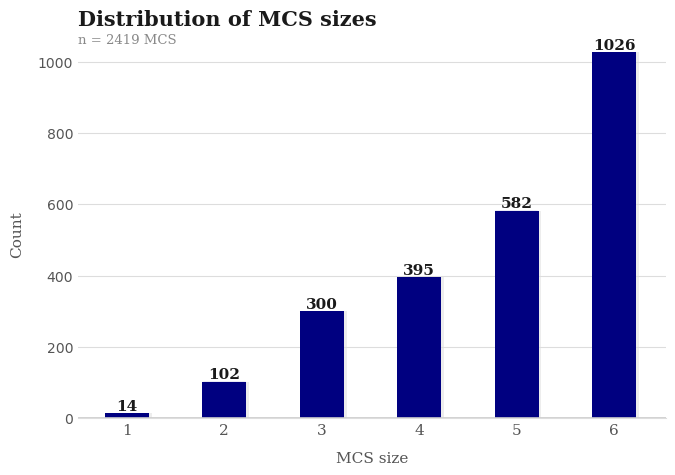

In [55]:
values, counts = np.unique(card, return_counts=True)
total = len(card)
proportions = counts / total

BG = "#FFFFFF"
C1 = "#000080"
COLORS = [C1] * len(values)
GRID = "#DDDDDD"
TEXT = "#1A1A1A"

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bar_width = 0.45
x = np.arange(len(values))

# --- Subtle shadow bars (depth effect) ---
for xi, c in zip(x, counts):
    ax.bar(
        xi + 0.03, c, width=bar_width, color="#DDDDDD", alpha=0.5, zorder=1, linewidth=0
    )

# --- Main bars ---
bars = ax.bar(
    x, counts, width=bar_width, color=COLORS, zorder=2, linewidth=0, clip_on=False
)

# --- Rounded top cap ---
for bar, color in zip(bars, COLORS):
    cap = mpatches.FancyBboxPatch(
        (bar.get_x(), bar.get_height() - 0.25),
        bar.get_width(),
        0.25,
        boxstyle="round,pad=0.0,rounding_size=0.08",
        linewidth=0,
        facecolor=color,
        zorder=3,
    )
    ax.add_patch(cap)

# --- Count labels above bars ---
for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.55,
        f"{count}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color=TEXT,
        fontfamily="serif",
    )

# --- Proportion strip at bottom of bars ---
for bar, color in zip(bars, COLORS):
    rect = plt.Rectangle(
        (bar.get_x(), 0),
        bar.get_width(),
        0.22,
        color=color,
        alpha=0.9,
        zorder=4,
        linewidth=0,
    )
    ax.add_patch(rect)

# --- Grid ---
ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# --- Axes formatting ---
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{int(v)}" for v in values], fontsize=11, fontfamily="serif", color=TEXT
)
ax.set_xlabel("MCS size", fontsize=11, color="#555555", fontfamily="serif", labelpad=10)
ax.set_ylabel("Count", fontsize=11, color="#555555", fontfamily="serif", labelpad=10)
ax.set_ylim(0, max(counts) + 5)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRID)
ax.tick_params(axis="both", which="both", length=0, colors="#555555")
ax.tick_params(axis="y", labelsize=10)

# --- Title ---
ax.set_title(
    "Distribution of MCS sizes",
    fontsize=15,
    fontweight="bold",
    fontfamily="serif",
    color=TEXT,
    pad=18,
    loc="left",
)
ax.text(
    0,
    1.01,
    f"n = {total} MCS",
    transform=ax.transAxes,
    fontsize=9.5,
    color="#888888",
    fontfamily="serif",
    va="bottom",
)

# --- Baseline ---
ax.axhline(0, color="#CCCCCC", linewidth=1.2, zorder=5)

plt.tight_layout(pad=1.6)
plt.savefig("distribution_mcs.png", dpi=600, bbox_inches="tight", facecolor=BG)

Validate cut sets with optlang

In [58]:
# results_cache_dir = None # do not cache preprocessing results
results_cache_dir = Path(".")  # cache preprocessing results (in the current directory)

In [90]:
mod = optlang_enumerator.cobra_cnapy.CNApyModel.read_sbml_model(
    "../../models" + model_name + ".xml"
)
# allow all reactions that are not boundary reactions as cuts (same as exclude_boundary_reactions_as_cuts option of compute_mcs)
cuts = np.array([not not r for r in mod.reactions])
reac_id = mod.reactions.list_attr("id")  # list of reaction IDs in the model
# define target (multiple targets are possible; each target can have multiple linear inequality constraints)
mod_mue_target = [
    [("Biomass_Ecoli_core_w_GAM", ">=", 0.01)]
]  # one target with one constraint, a.k.a. syntehtic lethals
# this constraint alone would not be sufficient, but there are uptake limits defined in the reaction bounds
# of the model that are integerated below, first, however, parse the constraint(s) and convert to matrix format
mod_mue_target = [
    mcs_computation.relations2leq_matrix(
        mcs_computation.parse_relations(
            t, reac_id_symbols=mcs_computation.get_reac_id_symbols(reac_id)
        ),
        reac_id,
    )
    for t in mod_mue_target
]
# now integrate the non-default reaction bounds from the network
mcs_computation.integrate_model_bounds(mod, mod_mue_target)
# this is just to show what the first (and only) target now looks like:
for c in mcs_computation.get_leq_constraints(mod, mod_mue_target)[0]:
    print(c, c.problem)

d1d4d5ca-4666-11f1-9c1a-bc2411973405: -1.0*Biomass_Ecoli_core_w_GAM + 1.0*Biomass_Ecoli_core_w_GAM_reverse_1a29b <= -0.01 None


In [91]:
# calculate MCS up to size 6 with "any MCS" enumeration method
mod_mcs, _ = mcs_computation.compute_mcs(
    mod,
    mod_mue_target,
    cuts=cuts,
    enum_method=3,
    max_mcs_size=6,
    network_compression=True,
    include_model_bounds=True,
    results_cache_dir=results_cache_dir,
)
print(len(mod_mcs), "MCS found.")
# show MCS as n-tuples of reaction IDs
mod_mcs_rxns = [tuple(reac_id[r] for r in mcs) for mcs in mod_mcs]

# check that all MCS disable the first (and only) target
print(
    all(
        mcs_computation.check_mcs(
            mod, mod_mue_target[0], mod_mcs, optlang.interface.INFEASIBLE
        )
    )
)

Loaded compressed model from model_split_subsets_compressed_c0d88a0095af70744a1f8fd956da6938
Using indicators.
Objective function is empty; set objective to self.minimize_sum_over_z
Found solution with objective value 1.0
MCS ['{GAPD|PGK}']
Found solution with objective value 1.0
MCS ['{CS|ACONTa|ACONTb}']
Found solution with objective value 1.0
MCS ['ICDHyr']
Found solution with objective value 1.0
MCS ['{Biomass_Ecoli_core_w_GAM|NH4t|EX_nh4_e}']
Found solution with objective value 4.0
CS ['PGI' 'FBP' 'TALA' 'TKT2'] -> MCS ['PGI' 'FBP' 'TALA']
Found solution with objective value 6.0
CS ['GND' '{FEM4|EX_h2_e}' '{ALCD2x|ETOHt2r|EX_etoh_e}' '{EDP1|EDP2}'
 '{ACt2r|EX_ac_e}' '{FORti|EX_for_e}'] -> MCS ['{FEM4|EX_h2_e}' '{ALCD2x|ETOHt2r|EX_etoh_e}']
Found solution with objective value 5.0
CS ['GND' 'PFL' '{ALCD2x|ETOHt2r|EX_etoh_e}' '{EDP1|EDP2}' '{ACt2r|EX_ac_e}'] -> MCS ['PFL' '{ALCD2x|ETOHt2r|EX_etoh_e}']
Found solution with objective value 6.0
CS ['GND' 'PFL' 'ACALD' 'FEM9' '{EDP1|EDP2}

In [92]:
converted_mets = [[mcs[i]["converted_mets"]][0] for i in range(len(mcs))]
converted_mets

[['GAPD', 'MW'],
 ['PGK', 'MW'],
 ['ICDHyr', 'MW'],
 ['PGM', 'MW'],
 ['Biomass_Ecoli_core_w_GAM', 'MW'],
 ['ENO', 'MW'],
 ['NH4t', 'MW'],
 ['EX_nh4_e', 'MW'],
 ['CS', 'MW'],
 ['ACONTa', 'MW'],
 ['ACONTb', 'MW'],
 ['GLCpts', 'MW'],
 ['EX_glc_e', 'MW'],
 ['RPI', 'MW'],
 ['PGI', 'G6PDH2r', 'MW'],
 ['PGI', 'PGL', 'MW'],
 ['PFL', 'EX_etoh_e', 'MW'],
 ['G6PDH2r', 'TALA_bw', 'MW'],
 ['GND', 'TALA_bw', 'MW'],
 ['PGL', 'TALA_bw', 'MW'],
 ['ALCD2x', 'TALA_bw', 'MW'],
 ['ETOHt2r', 'TALA_bw', 'MW'],
 ['EX_etoh_e', 'TALA_bw', 'MW'],
 ['PPC', 'ACALD', 'MW'],
 ['ACALD', 'MDH_bw', 'MW'],
 ['ACALD', 'FUM_bw', 'MW'],
 ['ALCD2x', 'MDH_bw', 'MW'],
 ['PPC', 'ALCD2x', 'MW'],
 ['EX_etoh_e', 'FUM_bw', 'MW'],
 ['PPC', 'EX_etoh_e', 'MW'],
 ['PPC', 'ETOHt2r', 'MW'],
 ['EX_etoh_e', 'MDH_bw', 'MW'],
 ['ETOHt2r', 'MDH_bw', 'MW'],
 ['ALCD2x', 'FUM_bw', 'MW'],
 ['ETOHt2r', 'FUM_bw', 'MW'],
 ['PPC', 'CO2t', 'MW'],
 ['ALCD2x', 'EX_succ_e', 'MW'],
 ['MDH', 'PPC', 'MW'],
 ['PPC', 'PFL', 'MW'],
 ['PPC', 'EX_co2_e', 'MW'],

In [93]:
# Convert mod_mcs_rxns tuples to sets of frozensets for easy comparison
mod_set = {frozenset(rxns) for rxns in mod_mcs_rxns}

# Compare converted_mets (ignoring 'MW') against mod_mcs_rxns
matches = []
for entry in converted_mets:
    rxns = frozenset(x for x in entry if x != "MW")
    if rxns in mod_set:
        matches.append(entry)

print(f"Number of matches: {len(matches)}")
print("Matched entries:")
for m in matches:
    print(m)

Number of matches: 2419
Matched entries:
['GAPD', 'MW']
['PGK', 'MW']
['ICDHyr', 'MW']
['PGM', 'MW']
['Biomass_Ecoli_core_w_GAM', 'MW']
['ENO', 'MW']
['NH4t', 'MW']
['EX_nh4_e', 'MW']
['CS', 'MW']
['ACONTa', 'MW']
['ACONTb', 'MW']
['GLCpts', 'MW']
['EX_glc_e', 'MW']
['RPI', 'MW']
['PGI', 'G6PDH2r', 'MW']
['PGI', 'PGL', 'MW']
['PFL', 'EX_etoh_e', 'MW']
['G6PDH2r', 'TALA_bw', 'MW']
['GND', 'TALA_bw', 'MW']
['PGL', 'TALA_bw', 'MW']
['ALCD2x', 'TALA_bw', 'MW']
['ETOHt2r', 'TALA_bw', 'MW']
['EX_etoh_e', 'TALA_bw', 'MW']
['PPC', 'ACALD', 'MW']
['ACALD', 'MDH_bw', 'MW']
['ACALD', 'FUM_bw', 'MW']
['ALCD2x', 'MDH_bw', 'MW']
['PPC', 'ALCD2x', 'MW']
['EX_etoh_e', 'FUM_bw', 'MW']
['PPC', 'EX_etoh_e', 'MW']
['PPC', 'ETOHt2r', 'MW']
['EX_etoh_e', 'MDH_bw', 'MW']
['ETOHt2r', 'MDH_bw', 'MW']
['ALCD2x', 'FUM_bw', 'MW']
['ETOHt2r', 'FUM_bw', 'MW']
['PPC', 'CO2t', 'MW']
['ALCD2x', 'EX_succ_e', 'MW']
['MDH', 'PPC', 'MW']
['PPC', 'PFL', 'MW']
['PPC', 'EX_co2_e', 'MW']
['PFL', 'MDH_bw', 'MW']
['PDH', 'PFL',